<a href="https://colab.research.google.com/github/zencod-646/VOWEL_A/blob/main/VOWEL%20A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# UNZIP DATASET
# =====================================

import zipfile

zip_path = "/content/modulated vowels.zip"

extract_path = "/content"

with zipfile.ZipFile(
    zip_path,
    'r'
) as zip_ref:

    zip_ref.extractall(
        extract_path
    )

print("Dataset extracted")

Dataset extracted


In [2]:

# =====================================
# DATASET PATH
# =====================================

dataset_path = "/content/modulated vowels"

In [3]:
# =====================================
# HYBRID FEATURE EXTRACTION
# =====================================

def extract_hybrid_features(filepath):

    audio, sr = librosa.load(
        filepath,
        sr=16000
    )

    features = []

    # -----------------------
    # MFCC
    # -----------------------

    mfcc = librosa.feature.mfcc(

        y=audio,

        sr=sr,

        n_mfcc=13
    )

    features.extend(
        np.mean(
            mfcc,
            axis=1
        )
    )

    features.extend(
        np.std(
            mfcc,
            axis=1
        )
    )

    # -----------------------
    # Spectral
    # -----------------------

    features.append(
        np.mean(
            librosa.feature.zero_crossing_rate(
                audio
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.rms(
                y=audio
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sr
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_bandwidth(
                y=audio,
                sr=sr
            )
        )
    )

    features.append(
        np.mean(
            librosa.feature.spectral_rolloff(
                y=audio,
                sr=sr
            )
        )
    )

    # -----------------------
    # Chroma
    # -----------------------

    chroma = librosa.feature.chroma_stft(

        y=audio,

        sr=sr
    )

    features.extend(
        np.mean(
            chroma,
            axis=1
        )
    )

    # -----------------------
    # Mel
    # -----------------------

    mel = librosa.feature.melspectrogram(

        y=audio,

        sr=sr,

        n_mels=20
    )

    features.extend(
        np.mean(
            mel,
            axis=1
        )
    )

    return np.array(
        features
    )

***MAX DEPTH = 2***

In [4]:
import os
import librosa
import numpy as np
# =====================================
# BUILD DATASET FOR VOWEL A
# =====================================

X = []

y = []

groups = []

for class_name in [

    "hc",

    "pd"
]:

    vowel_folder = os.path.join(

        dataset_path,

        class_name,

        "A"
    )

    for file in os.listdir(
        vowel_folder
    ):

        if file.endswith(
            ".wav"
        ):

            filepath = os.path.join(

                vowel_folder,

                file
            )

            feat = extract_hybrid_features(
                filepath
            )

            X.append(
                feat
            )

            y.append(

                0 if class_name=="hc"

                else 1
            )

            groups.append(
                file[10:14]
            )

X = np.array(X)

y = np.array(y)

groups = np.array(groups)

print(
    "Feature shape:",
    X.shape
)

print(
    "Samples:",
    len(X)
)



Feature shape: (100, 63)
Samples: 100


***MAX DEPTH = 2***

In [5]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# =====================================
# DECISION TREE
# =====================================

gkf = GroupKFold(
    n_splits=5
)

acc_scores = []

prec_scores = []

rec_scores = []

f1_scores = []

for train_idx, test_idx in gkf.split(

    X,

    y,

    groups
):

    X_train = X[
        train_idx
    ]

    X_test = X[
        test_idx
    ]

    y_train = y[
        train_idx
    ]

    y_test = y[
        test_idx
    ]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X_train
    )

    X_test = scaler.transform(
        X_test
    )

    model = DecisionTreeClassifier(

        max_depth=2,

        random_state=42
    )

    model.fit(

        X_train,

        y_train
    )

    pred = model.predict(
        X_test
    )

    acc_scores.append(

        accuracy_score(
            y_test,
            pred
        )
    )

    prec_scores.append(

        precision_score(
            y_test,
            pred
        )
    )

    rec_scores.append(

        recall_score(
            y_test,
            pred
        )
    )

    f1_scores.append(

        f1_score(
            y_test,
            pred
        )
    )

print()

print(
    "Accuracy:",
    np.mean(acc_scores)
)

print(
    "Precision:",
    np.mean(prec_scores)
)

print(
    "Recall:",
    np.mean(rec_scores)
)

print(
    "F1 Score:",
    np.mean(f1_scores)
)


Accuracy: 0.65
Precision: 0.6394871794871795
Recall: 0.6810101010101011
F1 Score: 0.645286734623119


  max_depth  Accuracy  Precision    Recall        F1
0         2      0.65   0.639487  0.681010  0.645287
1         3      0.65   0.627179  0.765051  0.685112
2         5      0.60   0.596667  0.600606  0.595811
3        10      0.62   0.616667  0.622828  0.615556
4        15      0.62   0.616667  0.622828  0.615556
5        17      0.62   0.616667  0.622828  0.615556
6        20      0.62   0.616667  0.622828  0.615556
7      None      0.62   0.616667  0.622828  0.615556


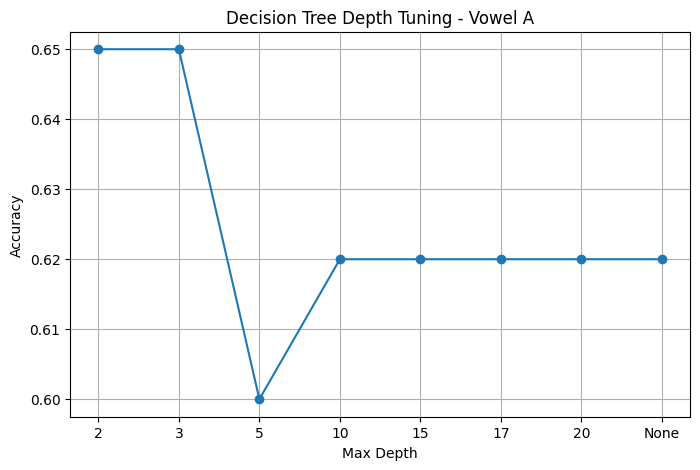

In [6]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

depths = [2, 3, 5, 10, 15,17,20, None]

results = []

for depth in depths:

    gkf = GroupKFold(
        n_splits=5
    )

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = DecisionTreeClassifier(
            max_depth=depth,
            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        str(depth),
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

# -----------------------
# Accuracy Graph
# -----------------------

plt.figure(figsize=(8,5))

plt.plot(
    results_df["max_depth"],
    results_df["Accuracy"],
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")

plt.title(
    "Decision Tree Depth Tuning - Vowel A"
)

plt.grid(True)

plt.show()

***TUNING MIN. SAMPLES LEAF***

   min_samples_leaf  Accuracy  Precision    Recall        F1
0                 1      0.65   0.627179  0.765051  0.685112
1                 2      0.65   0.631375  0.742828  0.679657
2                 4      0.66   0.640350  0.742828  0.685191
3                 8      0.65   0.633427  0.722828  0.671594
4                10      0.66   0.632821  0.755152  0.685440
5                12      0.67   0.652564  0.758788  0.698225
6                14      0.69   0.685043  0.738788  0.706463
7                16      0.68   0.687094  0.658788  0.658400
8                18      0.70   0.723077  0.638788  0.667843
9                20      0.72   0.763333  0.638788  0.679355


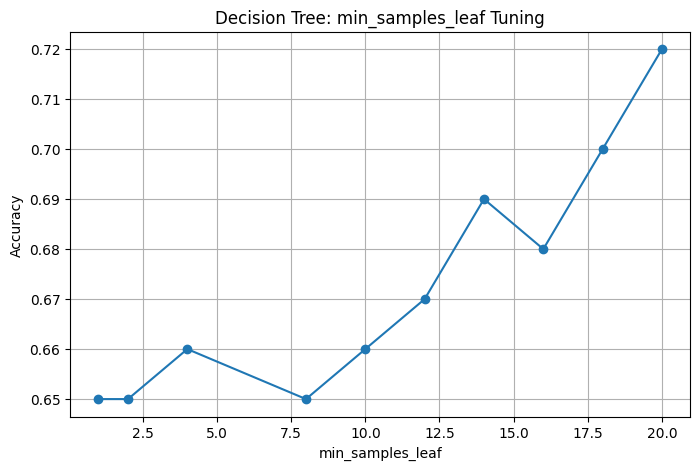

In [39]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BEST_DEPTH = 3   # replace with your best depth

leaf_values = [1, 2, 4, 8, 10,12,14,16,18,20]

results = []

for leaf in leaf_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = DecisionTreeClassifier(
            max_depth=BEST_DEPTH,
            min_samples_leaf=leaf,
            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc_scores.append(accuracy_score(y_test, pred))
        prec_scores.append(precision_score(y_test, pred, zero_division=0))
        rec_scores.append(recall_score(y_test, pred))
        f1_scores.append(f1_score(y_test, pred))

    results.append([
        leaf,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(8,5))
plt.plot(df["min_samples_leaf"], df["Accuracy"], marker="o")
plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")
plt.title("Decision Tree: min_samples_leaf Tuning")
plt.grid(True)
plt.show()

***BASED ON CRITERON***

  Criterion  Accuracy  Precision    Recall        F1
0      gini      0.60   0.596667  0.600606  0.595811
1   entropy      0.63   0.634286  0.600606  0.613767


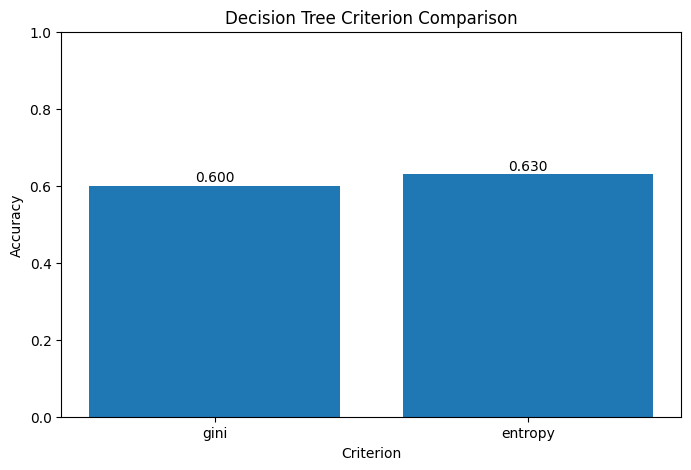

In [40]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# SET BEST VALUES FOUND SO FAR
# -----------------------------------

BEST_DEPTH = 5          # change if different
BEST_LEAF = 1           # change if different
BEST_SPLIT = 2          # change if different

criteria = [
    "gini",
    "entropy"
]

results = []

for crit in criteria:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = DecisionTreeClassifier(

            criterion=crit,

            max_depth=BEST_DEPTH,

            min_samples_leaf=BEST_LEAF,

            min_samples_split=BEST_SPLIT,

            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        crit,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Criterion",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# -----------------------------------
# PLOT
# -----------------------------------

plt.figure(figsize=(8,5))

plt.bar(
    df["Criterion"],
    df["Accuracy"]
)

plt.xlabel("Criterion")
plt.ylabel("Accuracy")

plt.title(
    "Decision Tree Criterion Comparison"
)

for i,v in enumerate(df["Accuracy"]):

    plt.text(
        i,
        v+0.01,
        f"{v:.3f}",
        ha="center"
    )

plt.ylim(
    0,
    1
)

plt.show()

**RANDOM FOREST**

---



*TUNING ESTIMATOR*

   n_estimators  Accuracy  Precision    Recall        F1
0            40      0.67   0.654825  0.718788  0.682236
1            50      0.69   0.661492  0.755152  0.703768
2           100      0.66   0.641299  0.716970  0.673636
3           300      0.65   0.645000  0.662424  0.644444
4           500      0.66   0.651667  0.680606  0.657778
5          1000      0.68   0.665455  0.718788  0.685104
6          1200      0.69   0.670000  0.736970  0.696171
7          1400      0.69   0.670000  0.736970  0.696171
8          1600      0.69   0.670000  0.736970  0.696171


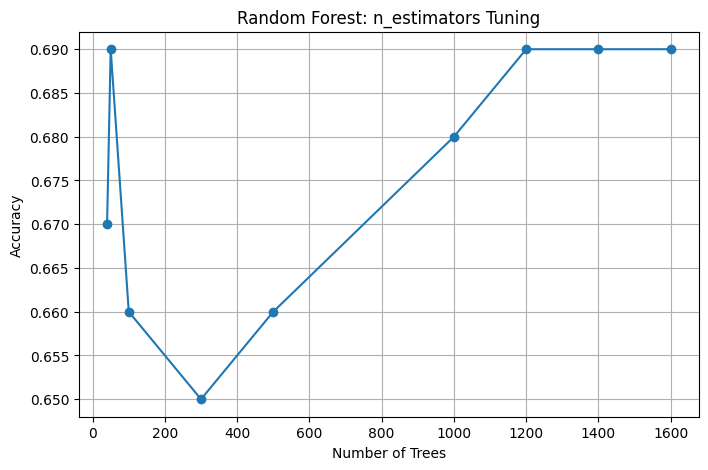

In [41]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

estimators = [
    40,
    50,
    100,
    300,
    500,
    1000,
    1200,
    1400,
    1600
]

results = []

for n in estimators:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = RandomForestClassifier(

            n_estimators=n,

            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        n,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "n_estimators",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(8,5))

plt.plot(
    df["n_estimators"],
    df["Accuracy"],
    marker='o'
)

plt.xlabel(
    "Number of Trees"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Random Forest: n_estimators Tuning"
)

plt.grid(True)

plt.show()

*TUNING MAX DEPTH* (keeping estimators = 50)

  max_depth  Accuracy  Precision    Recall        F1
0         3      0.60   0.587045  0.678788  0.623916
1         5      0.66   0.637965  0.736970  0.680909
2        10      0.69   0.661492  0.755152  0.703768
3        15      0.69   0.661492  0.755152  0.703768
4      None      0.69   0.661492  0.755152  0.703768


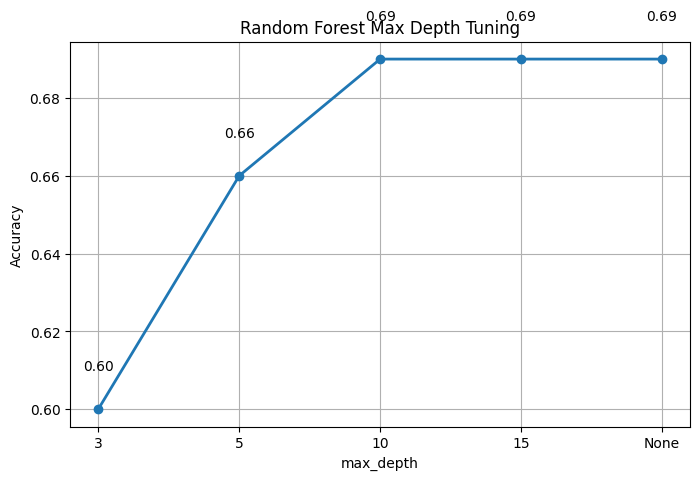

In [42]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# BEST VALUE FROM PREVIOUS EXPERIMENT
# ----------------------------------

BEST_ESTIMATORS = 50

depths = [
    3,
    5,
    10,
    15,
    None
]

results = []

for depth in depths:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = RandomForestClassifier(

            n_estimators=BEST_ESTIMATORS,

            max_depth=depth,

            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        str(depth),
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(

    results,

    columns=[
        "max_depth",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# PLOT ACCURACY
# ----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df["max_depth"],
    df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel(
    "max_depth"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Random Forest Max Depth Tuning"
)

plt.grid(True)

for i, v in enumerate(df["Accuracy"]):

    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.show()

*TUNING MIN SAMPLE LEAFS*  
Depth = 5 is the sweet spot

Highest F1 score.
Highest recall among the 73% accuracy models.
Simpler model than depth 10, 15, or None.

   min_samples_leaf  Accuracy  Precision    Recall        F1
0                 1      0.66   0.637965  0.736970  0.680909
1                 2      0.66   0.645758  0.696970  0.668894
2                 4      0.67   0.643310  0.735152  0.684720
3                 8      0.65   0.651966  0.680606  0.659732


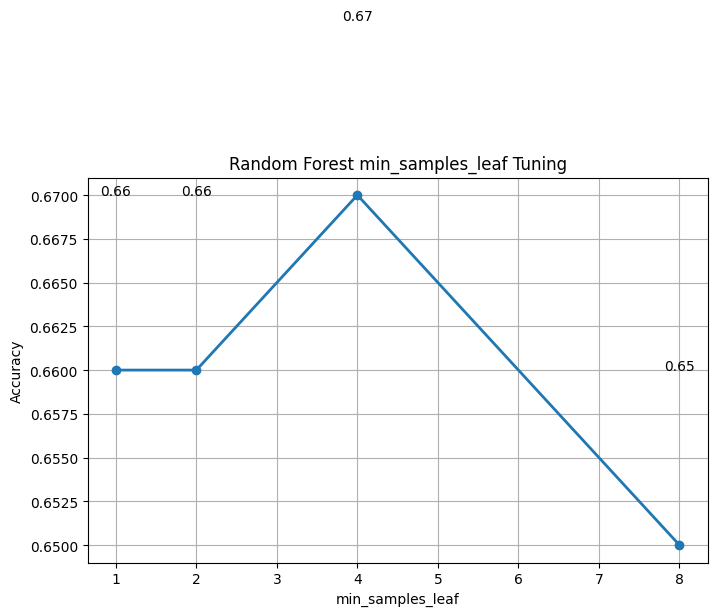

In [43]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# BEST PARAMETERS SO FAR
# ----------------------------------

BEST_ESTIMATORS = 50
BEST_DEPTH = 5

leaf_values = [1, 2, 4, 8]

results = []

for leaf in leaf_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestClassifier(

            n_estimators=BEST_ESTIMATORS,

            max_depth=BEST_DEPTH,

            min_samples_leaf=leaf,

            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        leaf,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "min_samples_leaf",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# PLOT
# ----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df["min_samples_leaf"],
    df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("min_samples_leaf")
plt.ylabel("Accuracy")

plt.title(
    "Random Forest min_samples_leaf Tuning"
)

plt.grid(True)

for i, v in enumerate(df["Accuracy"]):
    plt.text(
        df["min_samples_leaf"][i],
        v + 0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.show()

   min_samples_split  Accuracy  Precision    Recall        F1
0                  2      0.67   0.643310  0.735152  0.684720
1                  5      0.67   0.643310  0.735152  0.684720
2                 10      0.66   0.641299  0.716970  0.674238
3                 20      0.67   0.645758  0.735152  0.686121


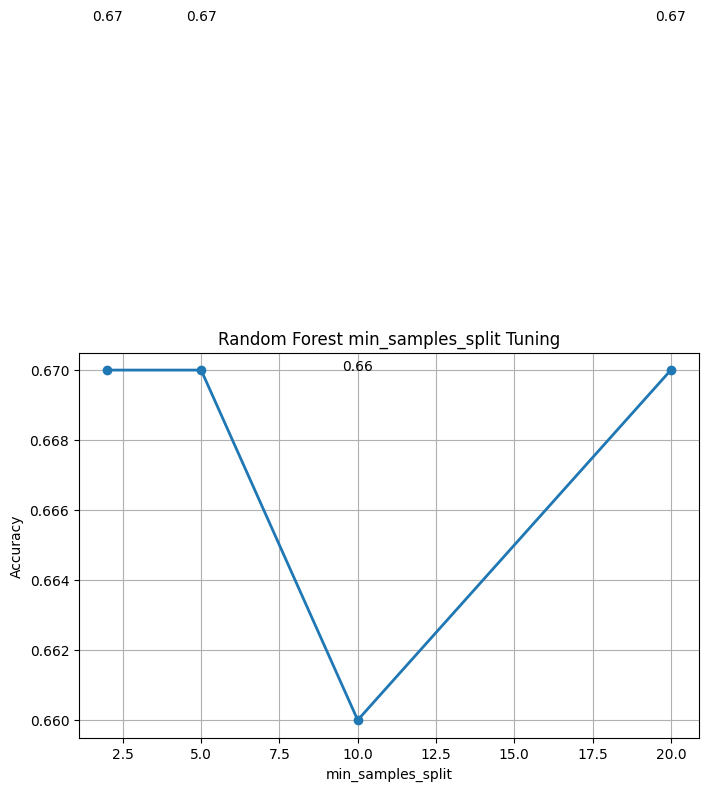

In [44]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# BEST PARAMETERS SO FAR
# ----------------------------------

BEST_ESTIMATORS = 50
BEST_DEPTH = 5
BEST_LEAF = 4

split_values = [2, 5, 10, 20]

results = []

for split in split_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestClassifier(

            n_estimators=BEST_ESTIMATORS,

            max_depth=BEST_DEPTH,

            min_samples_leaf=BEST_LEAF,

            min_samples_split=split,

            random_state=42
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        split,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "min_samples_split",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ---------------------------
# Plot Accuracy
# ---------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df["min_samples_split"],
    df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("min_samples_split")
plt.ylabel("Accuracy")

plt.title(
    "Random Forest min_samples_split Tuning"
)

plt.grid(True)

for x, y_val in zip(
    df["min_samples_split"],
    df["Accuracy"]
):
    plt.text(
        x,
        y_val + 0.01,
        f"{y_val:.2f}",
        ha="center"
    )

plt.show()

  max_features  Accuracy  Precision    Recall        F1
0         sqrt      0.66   0.641299  0.716970  0.674238
1         log2      0.65   0.628730  0.717374  0.665843
2         None      0.68   0.657529  0.741010  0.693562


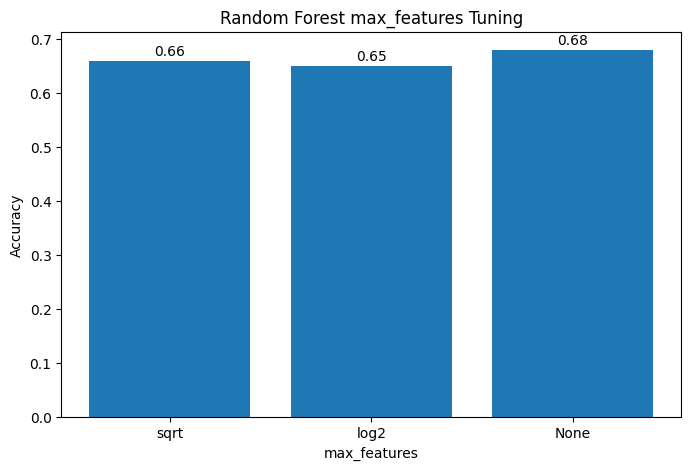

In [45]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BEST_ESTIMATORS = 50
BEST_DEPTH = 5
BEST_LEAF = 4
BEST_SPLIT = 10

feature_options = [
    "sqrt",
    "log2",
    None
]

results = []

for feat in feature_options:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = RandomForestClassifier(

            n_estimators=BEST_ESTIMATORS,

            max_depth=BEST_DEPTH,

            min_samples_leaf=BEST_LEAF,

            min_samples_split=BEST_SPLIT,

            max_features=feat,

            random_state=42
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

    results.append([
        str(feat),
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "max_features",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(8,5))

plt.bar(
    df["max_features"],
    df["Accuracy"]
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")

plt.title(
    "Random Forest max_features Tuning"
)

for i,v in enumerate(df["Accuracy"]):
    plt.text(
        i,
        v+0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.show()

***KNN - K NEAREST NEIGHBORS***

---

MODIFYING N NEIGHBORS

    K  Accuracy  Precision    Recall        F1
0   1      0.49   0.486032  0.399394  0.432054
1   3      0.57   0.585714  0.442020  0.493813
2   5      0.56   0.596465  0.460202  0.499467
3   7      0.55   0.546667  0.477980  0.501039
4   9      0.57   0.569264  0.459798  0.502381
5  11      0.61   0.597518  0.536566  0.559991
6  15      0.63   0.642222  0.516162  0.567018
7  18      0.58   0.675000  0.333131  0.416627
8  22      0.58   0.632381  0.357172  0.450065


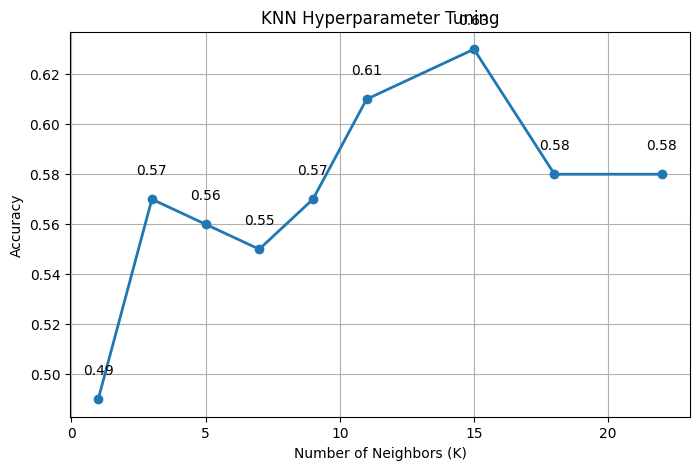

In [46]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# K VALUES TO TEST
# ----------------------------------

k_values = [1, 3, 5, 7, 9, 11, 15,18,22]

results = []

for k in k_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = KNeighborsClassifier(
            n_neighbors=k
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        k,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "K",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# GRAPH
# ----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    df["K"],
    df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")

plt.title(
    "KNN Hyperparameter Tuning"
)

plt.grid(True)

for x, y_val in zip(
    df["K"],
    df["Accuracy"]
):
    plt.text(
        x,
        y_val + 0.01,
        f"{y_val:.2f}",
        ha="center"
    )

plt.show()

TUNING WEIGHTS

    weights  Accuracy  Precision    Recall        F1
0   uniform      0.63   0.642222  0.516162  0.567018
1  distance      0.63   0.642222  0.516162  0.567018


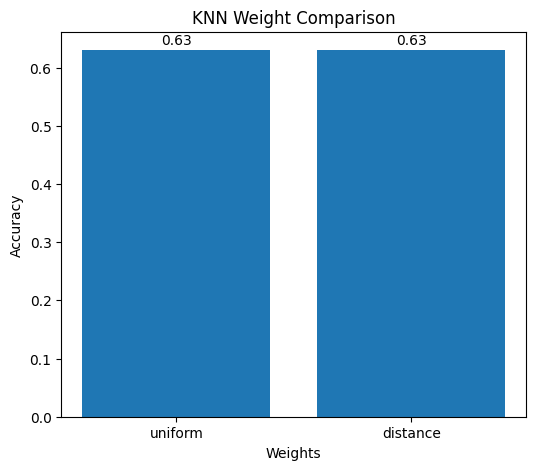

In [47]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BEST_K = 15

weight_options = [
    "uniform",
    "distance"
]

results = []

for wt in weight_options:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X, y, groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = KNeighborsClassifier(
            n_neighbors=BEST_K,
            weights=wt
        )

        model.fit(X_train, y_train)

        pred = model.predict(X_test)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

    results.append([
        wt,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "weights",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(6,5))

plt.bar(
    df["weights"],
    df["Accuracy"]
)

plt.xlabel("Weights")
plt.ylabel("Accuracy")

plt.title(
    "KNN Weight Comparison"
)

for i, v in enumerate(df["Accuracy"]):
    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.show()

***LOGISTIC REGESSION***

  Penalty       C  Accuracy  Precision    Recall        F1
0      l1    0.01      0.50   0.000000  0.000000  0.000000
1      l1    0.10      0.48   0.488333  0.443838  0.457143
2      l1    1.00      0.72   0.757619  0.658788  0.700111
3      l1   10.00      0.70   0.701410  0.703232  0.699181
4      l1  100.00      0.69   0.689643  0.703232  0.691930
5      l2    0.01      0.61   0.596212  0.626869  0.607528
6      l2    0.10      0.62   0.638095  0.564242  0.592008
7      l2    1.00      0.68   0.715232  0.640606  0.672515
8      l2   10.00      0.70   0.704899  0.705051  0.701271
9      l2  100.00      0.70   0.697778  0.726869  0.709893


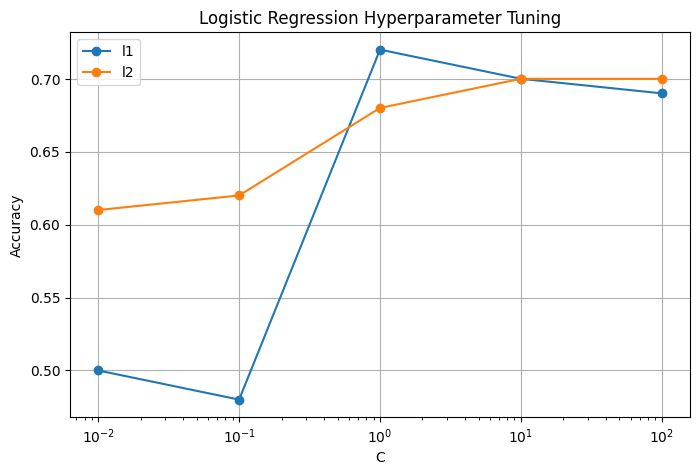

In [48]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

C_values = [0.01, 0.1, 1, 10, 100]
penalties = ["l1", "l2"]

results = []

for penalty in penalties:

    for C in C_values:

        acc_scores = []
        prec_scores = []
        rec_scores = []
        f1_scores = []

        gkf = GroupKFold(n_splits=5)

        for train_idx, test_idx in gkf.split(
            X,
            y,
            groups
        ):

            X_train = X[train_idx]
            X_test = X[test_idx]

            y_train = y[train_idx]
            y_test = y[test_idx]

            scaler = StandardScaler()

            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            model = LogisticRegression(
                penalty=penalty,
                C=C,
                solver="liblinear",
                max_iter=5000,
                random_state=42
            )

            model.fit(X_train, y_train)

            pred = model.predict(X_test)

            acc_scores.append(
                accuracy_score(y_test, pred)
            )

            prec_scores.append(
                precision_score(
                    y_test,
                    pred,
                    zero_division=0
                )
            )

            rec_scores.append(
                recall_score(y_test, pred)
            )

            f1_scores.append(
                f1_score(y_test, pred)
            )

        results.append([
            penalty,
            C,
            np.mean(acc_scores),
            np.mean(prec_scores),
            np.mean(rec_scores),
            np.mean(f1_scores)
        ])

df = pd.DataFrame(
    results,
    columns=[
        "Penalty",
        "C",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# Accuracy graph

plt.figure(figsize=(8,5))

for penalty in penalties:

    subset = df[df["Penalty"] == penalty]

    plt.plot(
        subset["C"],
        subset["Accuracy"],
        marker="o",
        label=penalty
    )

plt.xscale("log")

plt.xlabel("C")
plt.ylabel("Accuracy")

plt.title(
    "Logistic Regression Hyperparameter Tuning"
)

plt.legend()
plt.grid(True)

plt.show()

***SUPPORT VECTOR MACHINE***

---
TUNING C AND KERNEL



    Kernel      C  Accuracy  Precision    Recall        F1
0   linear    0.1      0.68   0.694488  0.644646  0.666133
1   linear    1.0      0.67   0.677424  0.684646  0.677469
2   linear   10.0      0.67   0.670758  0.706869  0.682482
3   linear  100.0      0.67   0.670758  0.706869  0.682482
4      rbf    0.1      0.53   0.429481  0.600000  0.489376
5      rbf    1.0      0.60   0.588132  0.586061  0.579293
6      rbf   10.0      0.64   0.627179  0.624646  0.619059
7      rbf  100.0      0.64   0.627179  0.624646  0.619059
8     poly    0.1      0.51   0.506409  0.963636  0.661905
9     poly    1.0      0.59   0.560532  0.921818  0.693143
10    poly   10.0      0.56   0.587857  0.462020  0.513421
11    poly  100.0      0.53   0.558095  0.379394  0.449526


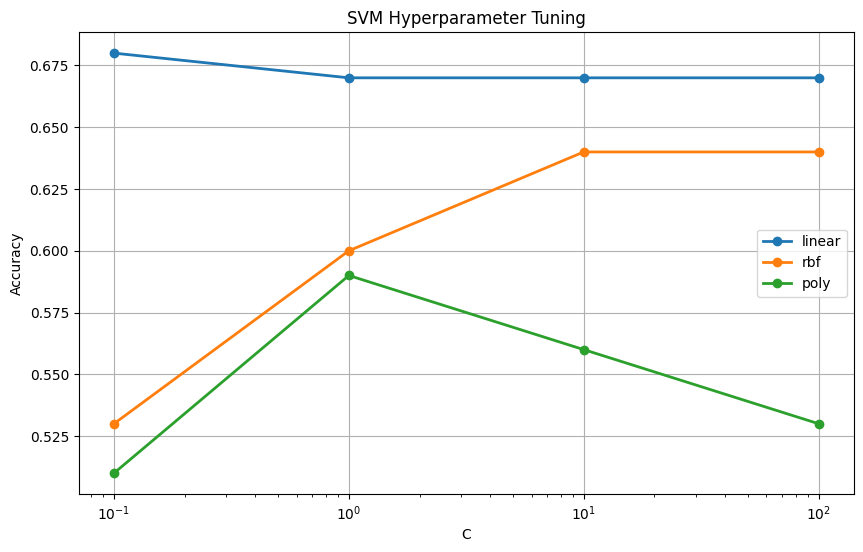

In [49]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# PARAMETERS TO TEST
# ----------------------------------

kernels = [
    "linear",
    "rbf",
    "poly"
]

C_values = [
    0.1,
    1,
    10,
    100
]

results = []

for kernel in kernels:

    for C in C_values:

        acc_scores = []
        prec_scores = []
        rec_scores = []
        f1_scores = []

        gkf = GroupKFold(
            n_splits=5
        )

        for train_idx, test_idx in gkf.split(
            X,
            y,
            groups
        ):

            X_train = X[train_idx]
            X_test = X[test_idx]

            y_train = y[train_idx]
            y_test = y[test_idx]

            scaler = StandardScaler()

            X_train = scaler.fit_transform(
                X_train
            )

            X_test = scaler.transform(
                X_test
            )

            model = SVC(

                kernel=kernel,

                C=C,

                random_state=42
            )

            model.fit(
                X_train,
                y_train
            )

            pred = model.predict(
                X_test
            )

            acc_scores.append(
                accuracy_score(
                    y_test,
                    pred
                )
            )

            prec_scores.append(
                precision_score(
                    y_test,
                    pred,
                    zero_division=0
                )
            )

            rec_scores.append(
                recall_score(
                    y_test,
                    pred
                )
            )

            f1_scores.append(
                f1_score(
                    y_test,
                    pred
                )
            )

        results.append([
            kernel,
            C,
            np.mean(acc_scores),
            np.mean(prec_scores),
            np.mean(rec_scores),
            np.mean(f1_scores)
        ])

df = pd.DataFrame(
    results,
    columns=[
        "Kernel",
        "C",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# GRAPH
# ----------------------------------

plt.figure(figsize=(10,6))

for kernel in kernels:

    subset = df[
        df["Kernel"] == kernel
    ]

    plt.plot(

        subset["C"],

        subset["Accuracy"],

        marker="o",

        linewidth=2,

        label=kernel
    )

plt.xscale("log")

plt.xlabel("C")

plt.ylabel("Accuracy")

plt.title(
    "SVM Hyperparameter Tuning"
)

plt.legend()

plt.grid(True)

plt.show()

***GAUSSIAN NAIVE BIAS***


---
VAR-SMOOTH TUNING


   var_smoothing  Accuracy  Precision    Recall        F1
0   1.000000e-12      0.47   0.480784  0.787273  0.594621
1   1.000000e-10      0.47   0.480784  0.787273  0.594621
2   1.000000e-09      0.47   0.480784  0.787273  0.594621
3   1.000000e-08      0.47   0.480784  0.787273  0.594621
4   1.000000e-07      0.47   0.480784  0.787273  0.594621
5   1.000000e-06      0.47   0.480784  0.787273  0.594621
6   1.000000e-05      0.47   0.480784  0.787273  0.594621


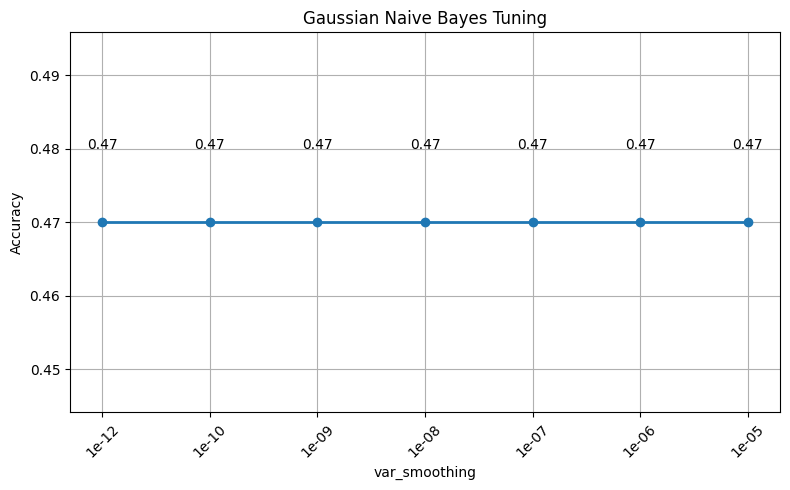

In [50]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# PARAMETERS TO TEST
# ----------------------------------

smoothing_values = [
    1e-12,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5
]

results = []

for smooth in smoothing_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        model = GaussianNB(
            var_smoothing=smooth
        )

        model.fit(
            X_train,
            y_train
        )

        pred = model.predict(
            X_test
        )

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        smooth,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "var_smoothing",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# GRAPH
# ----------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    range(len(df)),
    df["Accuracy"],
    marker="o",
    linewidth=2
)

plt.xticks(
    range(len(df)),
    [str(v) for v in df["var_smoothing"]],
    rotation=45
)

plt.xlabel("var_smoothing")
plt.ylabel("Accuracy")

plt.title(
    "Gaussian Naive Bayes Tuning"
)

plt.grid(True)

for i, v in enumerate(df["Accuracy"]):
    plt.text(
        i,
        v + 0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

***ANN***

---
TUNING HIDDEN NEURONS



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

   Neurons  Accuracy  Precision    Recall        F1
0       32      0.55   0.569048  0.386061  0.439216
1       64      0.54   0.535775  0.556566  0.539035
2      128      0.60   0.659121  0.437172  0.504454
3      256      0.54   0.600000  0.437172  0.479733


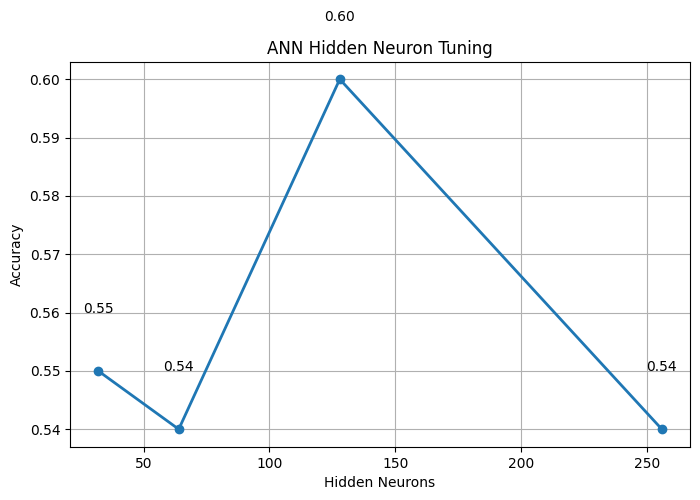

In [51]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------
# ANN PARAMETERS
# ----------------------------------

neuron_values = [
    32,
    64,
    128,
    256
]

results = []

for neurons in neuron_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(
        n_splits=5
    )

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(
            X_train
        )

        X_test = scaler.transform(
            X_test
        )

        tf.keras.backend.clear_session()

        model = Sequential([

            Dense(
                neurons,
                activation="relu",
                input_shape=(X_train.shape[1],)
            ),

            Dense(
                1,
                activation="sigmoid"
            )
        ])

        model.compile(

            optimizer="adam",

            loss="binary_crossentropy",

            metrics=["accuracy"]
        )

        early_stop = EarlyStopping(

            monitor="val_loss",

            patience=10,

            restore_best_weights=True
        )

        model.fit(

            X_train,

            y_train,

            validation_split=0.2,

            epochs=100,

            batch_size=8,

            verbose=0,

            callbacks=[early_stop]
        )

        pred_prob = model.predict(
            X_test,
            verbose=0
        )

        pred = (
            pred_prob > 0.5
        ).astype(int)

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([

        neurons,

        np.mean(acc_scores),

        np.mean(prec_scores),

        np.mean(rec_scores),

        np.mean(f1_scores)
    ])

df = pd.DataFrame(

    results,

    columns=[
        "Neurons",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

# ----------------------------------
# GRAPH
# ----------------------------------

plt.figure(figsize=(8,5))

plt.plot(

    df["Neurons"],

    df["Accuracy"],

    marker="o",

    linewidth=2
)

plt.xlabel(
    "Hidden Neurons"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "ANN Hidden Neuron Tuning"
)

plt.grid(True)

for x, y_val in zip(
    df["Neurons"],
    df["Accuracy"]
):

    plt.text(
        x,
        y_val + 0.01,
        f"{y_val:.2f}",
        ha="center"
    )

plt.show()

TUNING NO. OF HIDDEN LAYERS

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

  Architecture  Accuracy  Precision    Recall        F1
0     1_hidden      0.56   0.560000  0.737778  0.620602
1     2_hidden      0.61   0.650159  0.478384  0.546858
2     3_hidden      0.48   0.500000  0.586465  0.499443


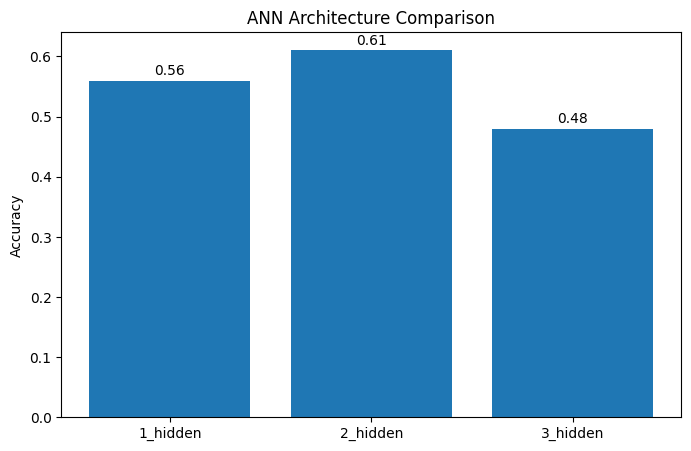

In [52]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

architectures = [
    "1_hidden",
    "2_hidden",
    "3_hidden"
]

results = []

for arch in architectures:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    gkf = GroupKFold(n_splits=5)

    for train_idx, test_idx in gkf.split(
        X,
        y,
        groups
    ):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        tf.keras.backend.clear_session()

        model = Sequential()

        if arch == "1_hidden":

            model.add(
                Dense(
                    64,
                    activation="relu",
                    input_shape=(X_train.shape[1],)
                )
            )

        elif arch == "2_hidden":

            model.add(
                Dense(
                    64,
                    activation="relu",
                    input_shape=(X_train.shape[1],)
                )
            )

            model.add(
                Dense(
                    32,
                    activation="relu"
                )
            )

        else:

            model.add(
                Dense(
                    64,
                    activation="relu",
                    input_shape=(X_train.shape[1],)
                )
            )

            model.add(
                Dense(
                    32,
                    activation="relu"
                )
            )

            model.add(
                Dense(
                    16,
                    activation="relu"
                )
            )

        model.add(
            Dense(
                1,
                activation="sigmoid"
            )
        )

        model.compile(

            optimizer="adam",

            loss="binary_crossentropy",

            metrics=["accuracy"]
        )

        early_stop = EarlyStopping(

            monitor="val_loss",

            patience=10,

            restore_best_weights=True
        )

        model.fit(

            X_train,

            y_train,

            validation_split=0.2,

            epochs=100,

            batch_size=8,

            verbose=0,

            callbacks=[early_stop]
        )

        pred_prob = model.predict(
            X_test,
            verbose=0
        )

        pred = (
            pred_prob > 0.5
        ).astype(int)

        acc_scores.append(
            accuracy_score(
                y_test,
                pred
            )
        )

        prec_scores.append(
            precision_score(
                y_test,
                pred,
                zero_division=0
            )
        )

        rec_scores.append(
            recall_score(
                y_test,
                pred
            )
        )

        f1_scores.append(
            f1_score(
                y_test,
                pred
            )
        )

    results.append([
        arch,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

df = pd.DataFrame(
    results,
    columns=[
        "Architecture",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(df)

plt.figure(figsize=(8,5))

plt.bar(
    df["Architecture"],
    df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("ANN Architecture Comparison")

for i,v in enumerate(df["Accuracy"]):
    plt.text(
        i,
        v+0.01,
        f"{v:.2f}",
        ha="center"
    )

plt.show()

TUNING LEARNING RATE


   Learning Rate  Accuracy  Precision    Recall        F1
0         0.0100      0.63   0.659524  0.604242  0.620024
1         0.0010      0.62   0.610000  0.604242  0.601882
2         0.0001      0.55   0.530350  0.483434  0.492464


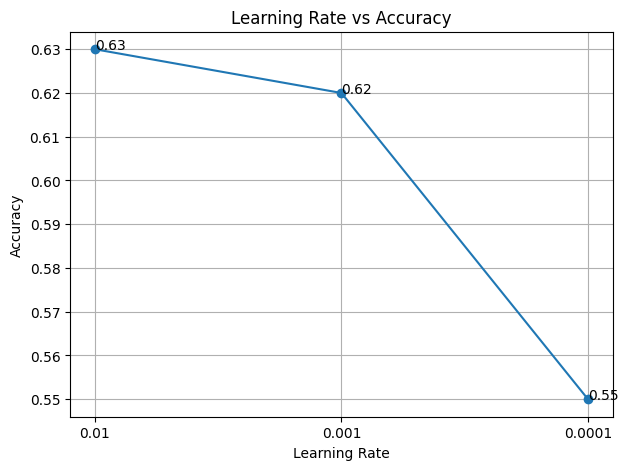

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

learning_rates = [0.01, 0.001, 0.0001]

results = []

gkf = GroupKFold(n_splits=5)

for lr in learning_rates:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation='tanh'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])

        optimizer = Adam(learning_rate=lr)

        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred_prob = model.predict(X_test, verbose=0)
        pred = (pred_prob > 0.5).astype(int)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(y_test, pred, zero_division=0)
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

    results.append([
        lr,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Learning Rate",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

# Plot
plt.figure(figsize=(7,5))

plt.plot(
    results_df["Learning Rate"].astype(str),
    results_df["Accuracy"],
    marker='o'
)

for x, y_val in zip(
    results_df["Learning Rate"].astype(str),
    results_df["Accuracy"]
):
    plt.text(x, y_val, f"{y_val:.2f}")

plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Accuracy")
plt.grid()
plt.show()

  Optimizer  Accuracy  Precision    Recall        F1
0      adam      0.56   0.616993  0.501616  0.514381
1   rmsprop      0.52   0.574396  0.534747  0.524417
2       sgd      0.60   0.730644  0.491515  0.495697


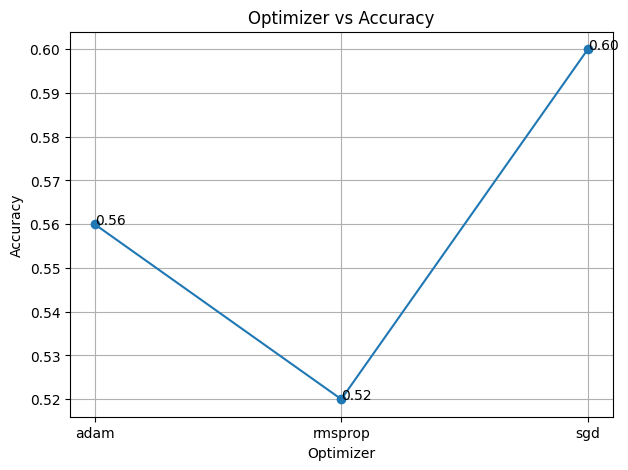

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

optimizer_names = ["adam", "rmsprop", "sgd"]

results = []

gkf = GroupKFold(n_splits=5)

for opt_name in optimizer_names:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=opt_name,
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred_prob = model.predict(X_test, verbose=0)
        pred = (pred_prob > 0.5).astype(int)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(y_test, pred, zero_division=0)
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

    results.append([
        opt_name,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Optimizer",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

# Plot
plt.figure(figsize=(7,5))

plt.plot(
    results_df["Optimizer"],
    results_df["Accuracy"],
    marker='o'
)

for x, y_val in zip(
    results_df["Optimizer"],
    results_df["Accuracy"]
):
    plt.text(
        x,
        y_val,
        f"{y_val:.2f}"
    )

plt.xlabel("Optimizer")
plt.ylabel("Accuracy")
plt.title("Optimizer vs Accuracy")
plt.grid()
plt.show()

   Batch Size  Accuracy  Precision    Recall        F1
0           4      0.54   0.545714  0.361212  0.423333
1           8      0.44   0.402222  0.403434  0.371144
2          16      0.49   0.525556  0.538788  0.502093
3          32      0.53   0.544286  0.557980  0.537977


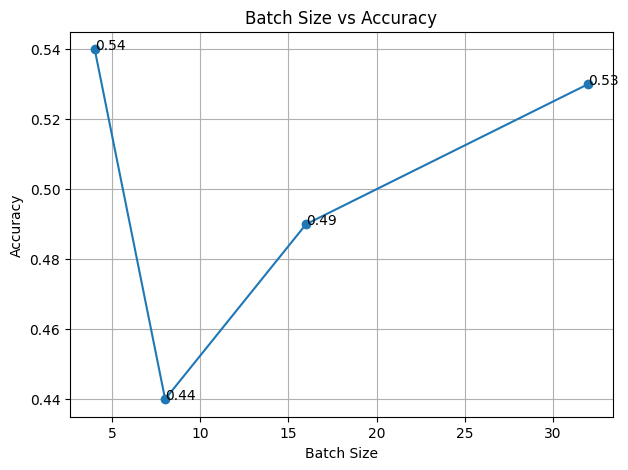

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD

batch_sizes = [4, 8, 16, 32]

results = []

gkf = GroupKFold(n_splits=5)

for batch_size in batch_sizes:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        model = Sequential([
            Input(shape=(X_train.shape[1],)),
            Dense(64, activation='relu'),
            Dropout(0.2),
            Dense(1, activation='sigmoid')
        ])

        model.compile(
            optimizer=SGD(learning_rate=0.01),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=batch_size,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred_prob = model.predict(X_test, verbose=0)
        pred = (pred_prob > 0.5).astype(int)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(y_test, pred, zero_division=0)
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

    results.append([
        batch_size,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Batch Size",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

# Plot
plt.figure(figsize=(7,5))

plt.plot(
    results_df["Batch Size"],
    results_df["Accuracy"],
    marker='o'
)

for x, y_val in zip(
    results_df["Batch Size"],
    results_df["Accuracy"]
):
    plt.text(
        x,
        y_val,
        f"{y_val:.2f}"
    )

plt.xlabel("Batch Size")
plt.ylabel("Accuracy")
plt.title("Batch Size vs Accuracy")
plt.grid()
plt.show()

***CONVOLUTIONAL NEURAL NETWORK***

In [18]:
import os
import numpy as np
import librosa

X = []
y = []
groups = []

dataset_path = "/content/modulated vowels"

for cls in ["hc", "pd"]:

    label = 0 if cls == "hc" else 1

    folder = os.path.join(dataset_path, cls, "A")

    for file in os.listdir(folder):

        if file.endswith(".wav"):

            filepath = os.path.join(folder, file)

            audio, sr = librosa.load(filepath, sr=16000)

            mel = librosa.feature.melspectrogram(
                y=audio,
                sr=sr,
                n_mels=64
            )

            mel_db = librosa.power_to_db(mel)

            # Make 64×64
            if mel_db.shape[1] < 64:

                pad = 64 - mel_db.shape[1]

                mel_db = np.pad(
                    mel_db,
                    ((0,0),(0,pad)),
                    mode='constant'
                )

            else:

                mel_db = mel_db[:, :64]

            X.append(mel_db)
            y.append(label)

            # Subject ID
            groups.append(file[10:14])

X = np.array(X, dtype=np.float32)
y = np.array(y)
groups = np.array(groups)

# Normalize
X = (X - X.mean()) / (X.std() + 1e-8)

# Add channel dimension
X = X[..., np.newaxis]

print(X.shape)

(100, 64, 64, 1)


FILTER TUNING


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import GroupKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

filter_values = [16,32,64,128]

results = []

gkf = GroupKFold(n_splits=5)

for filters in filter_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        model = Sequential([

            Input(shape=(64,64,1)),

            Conv2D(filters, (3,3), activation='relu'),
            MaxPooling2D((2,2)),

            Conv2D(filters*2, (3,3), activation='relu'),
            MaxPooling2D((2,2)),

            GlobalAveragePooling2D(),

            Dense(64, activation='relu'),

            Dropout(0.3),

            Dense(1, activation='sigmoid')

        ])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=4,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)

        acc_scores.append(
            accuracy_score(y_test, pred)
        )

        prec_scores.append(
            precision_score(y_test, pred, zero_division=0)
        )

        rec_scores.append(
            recall_score(y_test, pred)
        )

        f1_scores.append(
            f1_score(y_test, pred)
        )

        del model
        K.clear_session()
        gc.collect()

    results.append([
        filters,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Filters",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Filters"],
    results_df["Accuracy"],
    marker='o'
)

for x, y_ in zip(
    results_df["Filters"],
    results_df["Accuracy"]
):
    plt.text(x, y_, f"{y_:.2f}")

plt.xlabel("Filters")
plt.ylabel("Accuracy")
plt.title("CNN Filters vs Accuracy")
plt.grid()
plt.show()

UnknownError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelbase.py", line 510, in dispatch_queue

  File "/usr/local/lib/python3.12/dist-packages/ipyk

KERNEL SIZE

  Kernel Size  Accuracy  Precision    Recall        F1
0      (3, 3)      0.49   0.584603  0.713333  0.530266
1      (5, 5)      0.58   0.587803  0.797980  0.641572
2      (7, 7)      0.52   0.505714  0.800000  0.603739


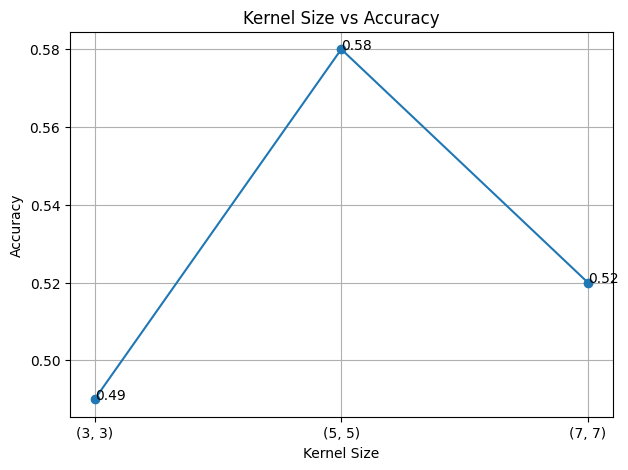

In [12]:
kernel_values = [(3,3), (5,5), (7,7)]

results = []

for kernel in kernel_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        model = Sequential([

            Input(shape=(128,128,1)),

            Conv2D(
                64,
                kernel,
                activation='relu'
            ),

            MaxPooling2D((2,2)),

            Flatten(),

            Dense(64, activation='relu'),

            Dropout(0.2),

            Dense(1, activation='sigmoid')

        ])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)

        acc_scores.append(accuracy_score(y_test, pred))
        prec_scores.append(precision_score(y_test, pred, zero_division=0))
        rec_scores.append(recall_score(y_test, pred))
        f1_scores.append(f1_score(y_test, pred))

    results.append([
        str(kernel),
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Kernel Size",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

plt.figure(figsize=(7,5))
plt.plot(results_df["Kernel Size"],
         results_df["Accuracy"],
         marker='o')

for x, y_ in zip(results_df["Kernel Size"],
                 results_df["Accuracy"]):
    plt.text(x, y_, f"{y_:.2f}")

plt.xlabel("Kernel Size")
plt.ylabel("Accuracy")
plt.title("Kernel Size vs Accuracy")
plt.grid()
plt.show()

DENSE UNITS

In [7]:
dense_values = [32, 64, 128]

results = []

for dense_units in dense_values:

    acc_scores = []
    prec_scores = []
    rec_scores = []
    f1_scores = []

    for train_idx, test_idx in gkf.split(X, y, groups):

        X_train = X[train_idx]
        X_test = X[test_idx]

        y_train = y[train_idx]
        y_test = y[test_idx]

        model = Sequential([

            Input(shape=(128,128,1)),

            Conv2D(
                64,
                (5,5),
                activation='relu'
            ),

            MaxPooling2D((2,2)),

            Flatten(),

            Dense(dense_units, activation='relu'),

            Dropout(0.2),

            Dense(1, activation='sigmoid')

        ])

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )

        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=8,
            validation_split=0.2,
            verbose=0,
            callbacks=[early_stop]
        )

        pred = (model.predict(X_test, verbose=0) > 0.5).astype(int)

        acc_scores.append(accuracy_score(y_test, pred))
        prec_scores.append(precision_score(y_test, pred, zero_division=0))
        rec_scores.append(recall_score(y_test, pred))
        f1_scores.append(f1_score(y_test, pred))

    results.append([
        dense_units,
        np.mean(acc_scores),
        np.mean(prec_scores),
        np.mean(rec_scores),
        np.mean(f1_scores)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Dense Units",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(results_df)

plt.figure(figsize=(7,5))

plt.plot(
    results_df["Dense Units"],
    results_df["Accuracy"],
    marker='o'
)

for x, y_ in zip(
    results_df["Dense Units"],
    results_df["Accuracy"]
):
    plt.text(x, y_, f"{y_:.2f}")

plt.xlabel("Dense Units")
plt.ylabel("Accuracy")
plt.title("Dense Units vs Accuracy")
plt.grid()
plt.show()

NameError: name 'Sequential' is not defined